# Pairs Trading — Results Analysis

In [1]:
import json, numpy as np, pandas as pd, matplotlib, matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

ROOT = Path(".").resolve().parent
OUTPUT = ROOT / "output"
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

ARMS = ["classic", "autoencoder", "gru"]
ARM_LABELS = {"classic": "Classic", "autoencoder": "Autoencoder", "gru": "GRU"}

# ── Palette (from lab presentation pptx theme) ──
C_TEAL      = "#156082"  # classic
C_PURPLE    = "#A02B93"  # autoencoder
C_TURQUOISE = "#0F9ED5"  # gru
C_NAVY      = "#0E2841"
C_ORANGE    = "#E97132"
C_MAROON    = "#C00000"
C_GREEN     = "#196B24"
C_ROSE      = "#96607D"
C_GOLD      = "#FFC000"
C_DARKTEAL  = "#467886"
C_GRAY      = "#404040"
C_LIGHTGRAY = "#E8E8E8"

ARM_COLORS = {"classic": C_TEAL, "autoencoder": C_PURPLE, "gru": C_TURQUOISE}
BARS_PER_YEAR = 3024

# ── Matplotlib style ──
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C_GRAY, "axes.labelcolor": C_NAVY,
    "axes.titleweight": "bold", "axes.titlecolor": C_NAVY,
    "axes.grid": True, "grid.color": C_LIGHTGRAY, "grid.linewidth": 0.5,
    "grid.linestyle": "--",
    "xtick.color": C_GRAY, "ytick.color": C_GRAY,
    "font.family": "sans-serif",
    "font.sans-serif": ["Calibri", "Helvetica", "Arial"],
    "font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11,
    "legend.framealpha": 0.9, "legend.edgecolor": C_LIGHTGRAY,
    "figure.dpi": 150, "savefig.dpi": 200, "savefig.bbox": "tight",
})

def savefig(fig, name):
    fig.savefig(RESULTS / f"{name}.png", facecolor="white")
    print(f"  -> {name}.png")

In [2]:
# ── Load all data ──
agg, equity, fold_metrics, trade_logs = {}, {}, {}, {}
for arm in ARMS:
    arm_dir = OUTPUT / arm
    with open(arm_dir / "aggregate_metrics.json") as f:
        agg[arm] = json.load(f)
    with open(arm_dir / "equity_curve.json") as f:
        d = json.load(f)
        equity[arm] = pd.Series(d["equity"], index=pd.to_datetime(d["timestamps"]), name=arm)
    with open(arm_dir / "fold_metrics.json") as f:
        fold_metrics[arm] = pd.DataFrame(json.load(f))
    with open(arm_dir / "trade_log.json") as f:
        trade_logs[arm] = pd.DataFrame(json.load(f))

# Summary table
summary_df = pd.DataFrame(agg).T
summary_df.index.name = "arm"
summary_df.to_csv(RESULTS / "summary_metrics.tsv", sep="\t", float_format="%.6f")
display(summary_df[["sharpe_annualized", "return_total", "return_annualized",
                     "max_drawdown", "n_trades", "trade_win_rate", "n_active_pairs",
                     "turnover_annualized", "avg_holding_bars"]].round(4))

,sharpe_annualized,return_total,return_annualized,max_drawdown,n_trades,trade_win_rate,n_active_pairs,turnover_annualized,avg_holding_bars
arm,,,,,,,,,
classic,0.0343,0.0041,0.0004,-0.0604,1674.0,0.5269,11.5294,30.5312,56.2545
autoencoder,-0.2064,-0.0619,-0.0069,-0.1003,892.0,0.4854,6.5294,27.8290,61.6289
gru,0.2662,0.2042,0.0205,-0.2573,544.0,0.5165,3.7059,31.5638,55.4338


## 1. Equity Curves (all arms overlaid) + Drawdown

  -> equity_curves.png


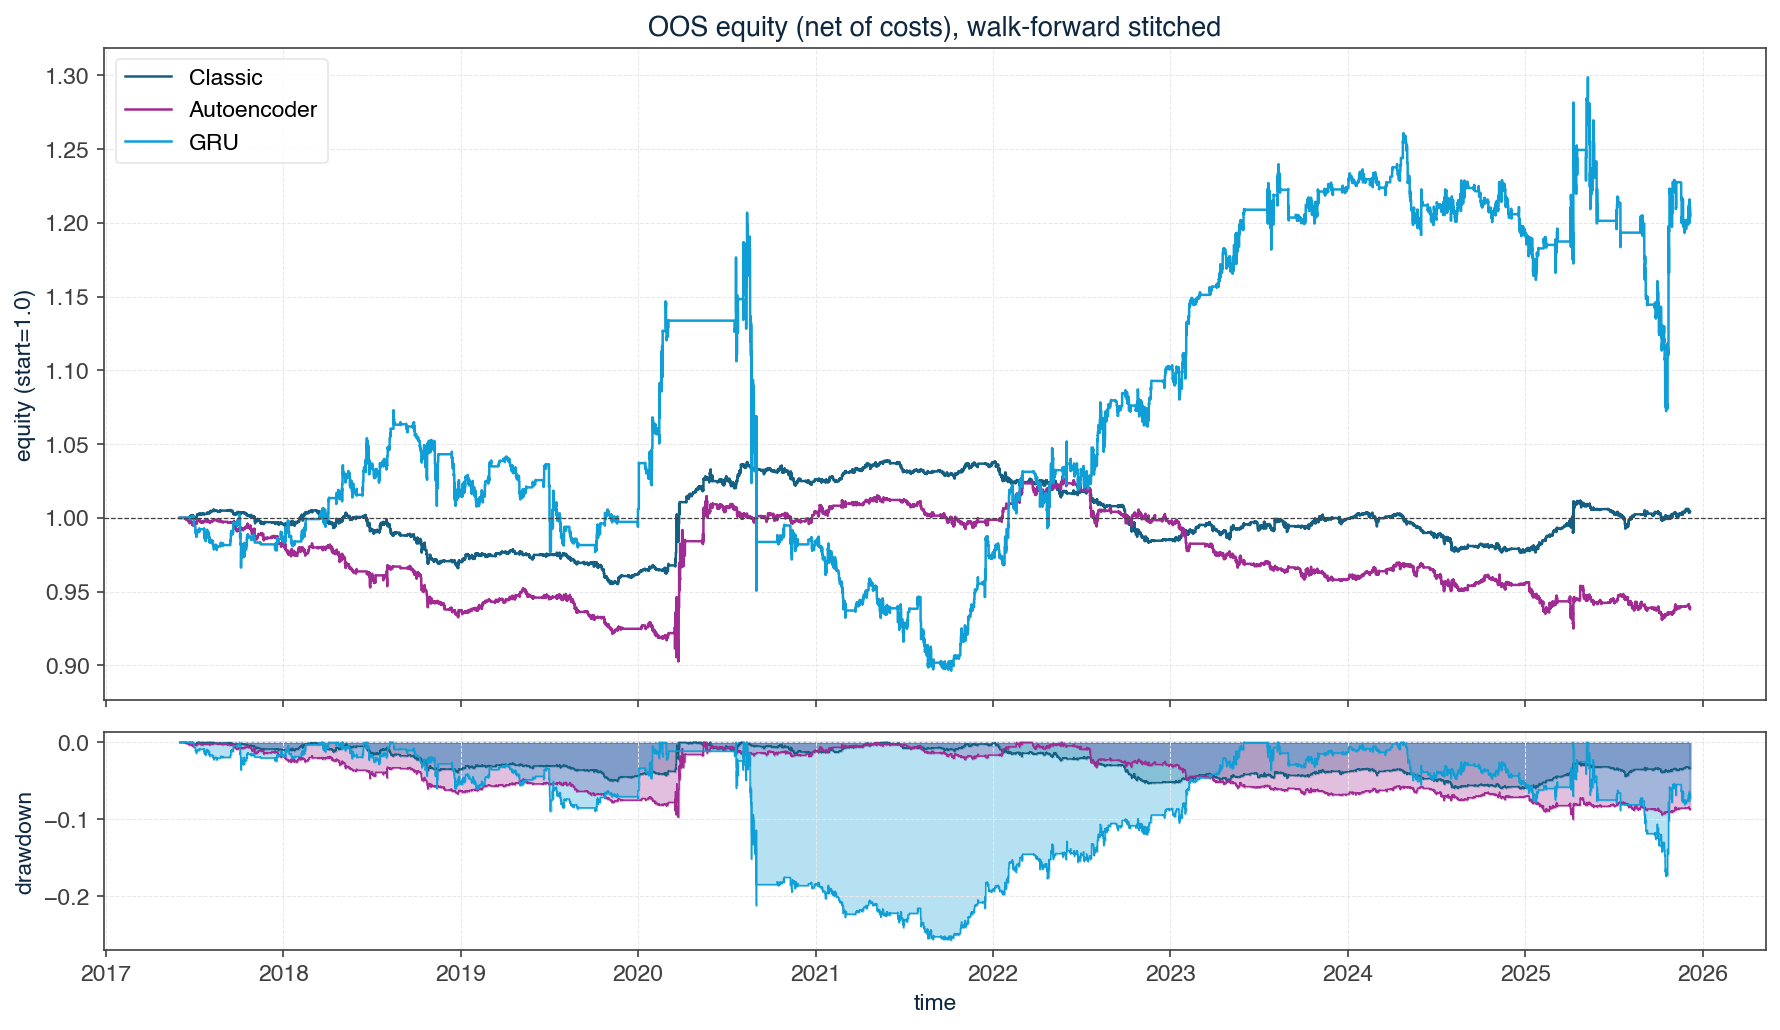

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
for arm in ARMS:
    eq = equity[arm]
    ax1.plot(eq.index, eq.values, label=ARM_LABELS[arm],
             color=ARM_COLORS[arm], linewidth=1.2)
    dd = eq / eq.cummax() - 1.0
    ax2.fill_between(dd.index, dd.values, 0, alpha=0.3, color=ARM_COLORS[arm])
    ax2.plot(dd.index, dd.values, color=ARM_COLORS[arm], linewidth=0.7)

ax1.axhline(1.0, color=C_GRAY, linewidth=0.6, linestyle="--")
ax1.set_title("OOS equity (net of costs), walk-forward stitched")
ax1.set_ylabel("equity (start=1.0)")
ax1.legend(loc="upper left")
ax2.set_ylabel("drawdown")
ax2.set_xlabel("time")
fig.tight_layout()
savefig(fig, "equity_curves")

## 2. Per-arm equity + drawdown (Daniel-style)

In [4]:
for arm in ARMS:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                    gridspec_kw={"height_ratios": [3, 1]})
    eq = equity[arm]
    dd = eq / eq.cummax() - 1.0
    ax1.plot(eq.index, eq.values, color=ARM_COLORS[arm], linewidth=1.0)
    ax1.axhline(1.0, color=C_GRAY, linewidth=0.6, linestyle="--")
    ax1.set_title(f"{ARM_LABELS[arm]} pairs \u2014 OOS equity (net of costs), walk-forward stitched")
    ax1.set_ylabel("equity (start=1.0)")
    ax2.fill_between(dd.index, dd.values, 0, alpha=0.35, color=C_MAROON)
    ax2.plot(dd.index, dd.values, color=C_MAROON, linewidth=0.7)
    ax2.set_ylabel("drawdown")
    ax2.set_xlabel("time")
    fig.tight_layout()
    savefig(fig, f"{arm}_equity_curve")
    plt.close(fig)

  -> classic_equity_curve.png


  -> autoencoder_equity_curve.png


  -> gru_equity_curve.png


## 3. Per-fold OOS Sharpe over time (line plot, Daniel-style)

  -> eda_fold_sharpe.png


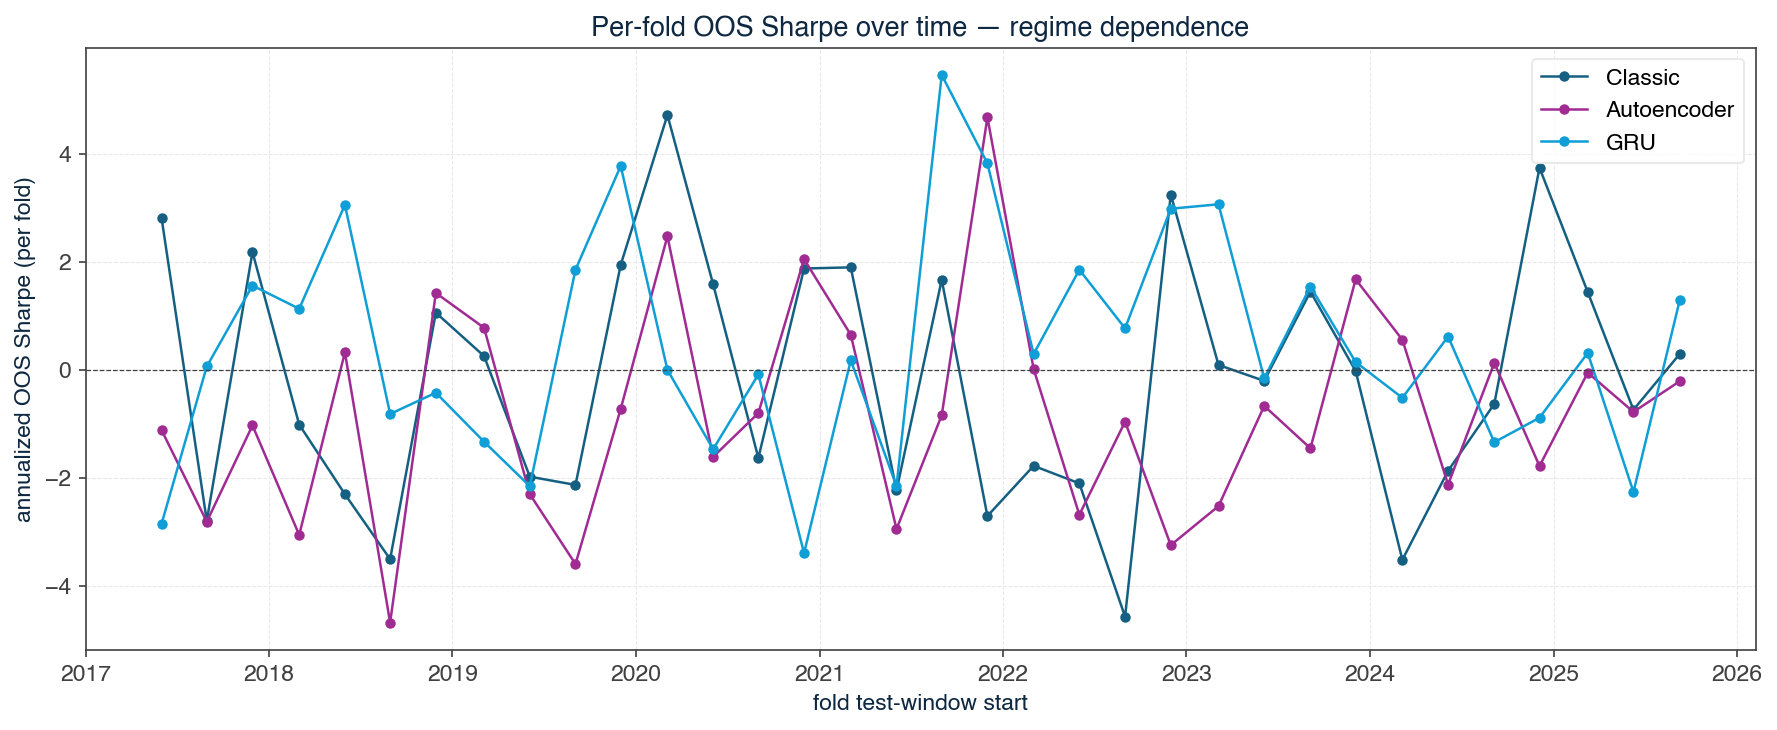

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
for arm in ARMS:
    fm = fold_metrics[arm]
    dates = pd.to_datetime(fm["test_start"])
    ax.plot(dates, fm["sharpe_annualized"], marker="o", markersize=4,
            label=ARM_LABELS[arm], color=ARM_COLORS[arm], linewidth=1.2)
ax.axhline(0, color=C_GRAY, linewidth=0.6, linestyle="--")
ax.set_title("Per-fold OOS Sharpe over time \u2014 regime dependence")
ax.set_ylabel("annualized OOS Sharpe (per fold)")
ax.set_xlabel("fold test-window start")
ax.legend()
fig.tight_layout()
savefig(fig, "eda_fold_sharpe")

# Save fold metrics TSVs
for arm in ARMS:
    fold_metrics[arm].to_csv(RESULTS / f"{arm}_fold_metrics.tsv", sep="\t",
                              index=False, float_format="%.6f")

## 4. Trade distributions (overlaid step histograms, Daniel-style)

  -> eda_trade_dists.png


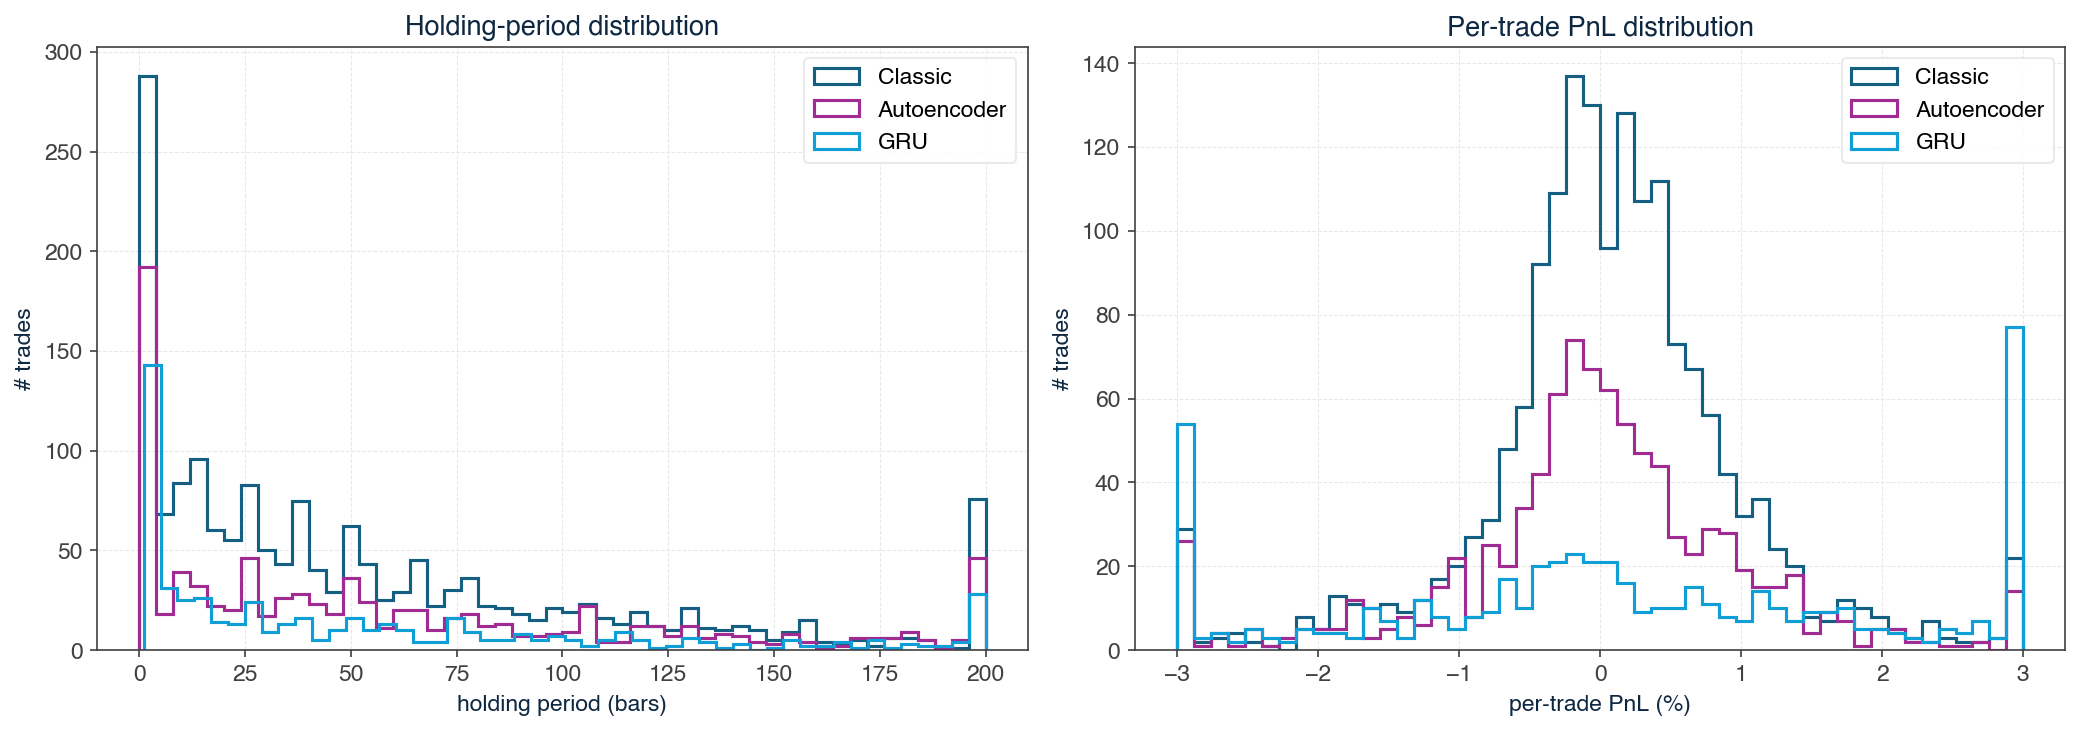

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Holding period
for arm in ARMS:
    tl = trade_logs[arm]
    if len(tl) == 0: continue
    ax1.hist(tl["holding_bars"].clip(upper=200), bins=50, histtype="step",
             linewidth=1.5, color=ARM_COLORS[arm], label=ARM_LABELS[arm])
ax1.set_title("Holding-period distribution")
ax1.set_xlabel("holding period (bars)")
ax1.set_ylabel("# trades")
ax1.legend()

# PnL
for arm in ARMS:
    tl = trade_logs[arm]
    if len(tl) == 0: continue
    ax2.hist(tl["pnl"].clip(-0.03, 0.03) * 100, bins=50, histtype="step",
             linewidth=1.5, color=ARM_COLORS[arm], label=ARM_LABELS[arm])
ax2.set_title("Per-trade PnL distribution")
ax2.set_xlabel("per-trade PnL (%)")
ax2.set_ylabel("# trades")
ax2.legend()
fig.tight_layout()
savefig(fig, "eda_trade_dists")

## 5. Cost sensitivity (Daniel-style)

  -> robustness_cost_sensitivity.png


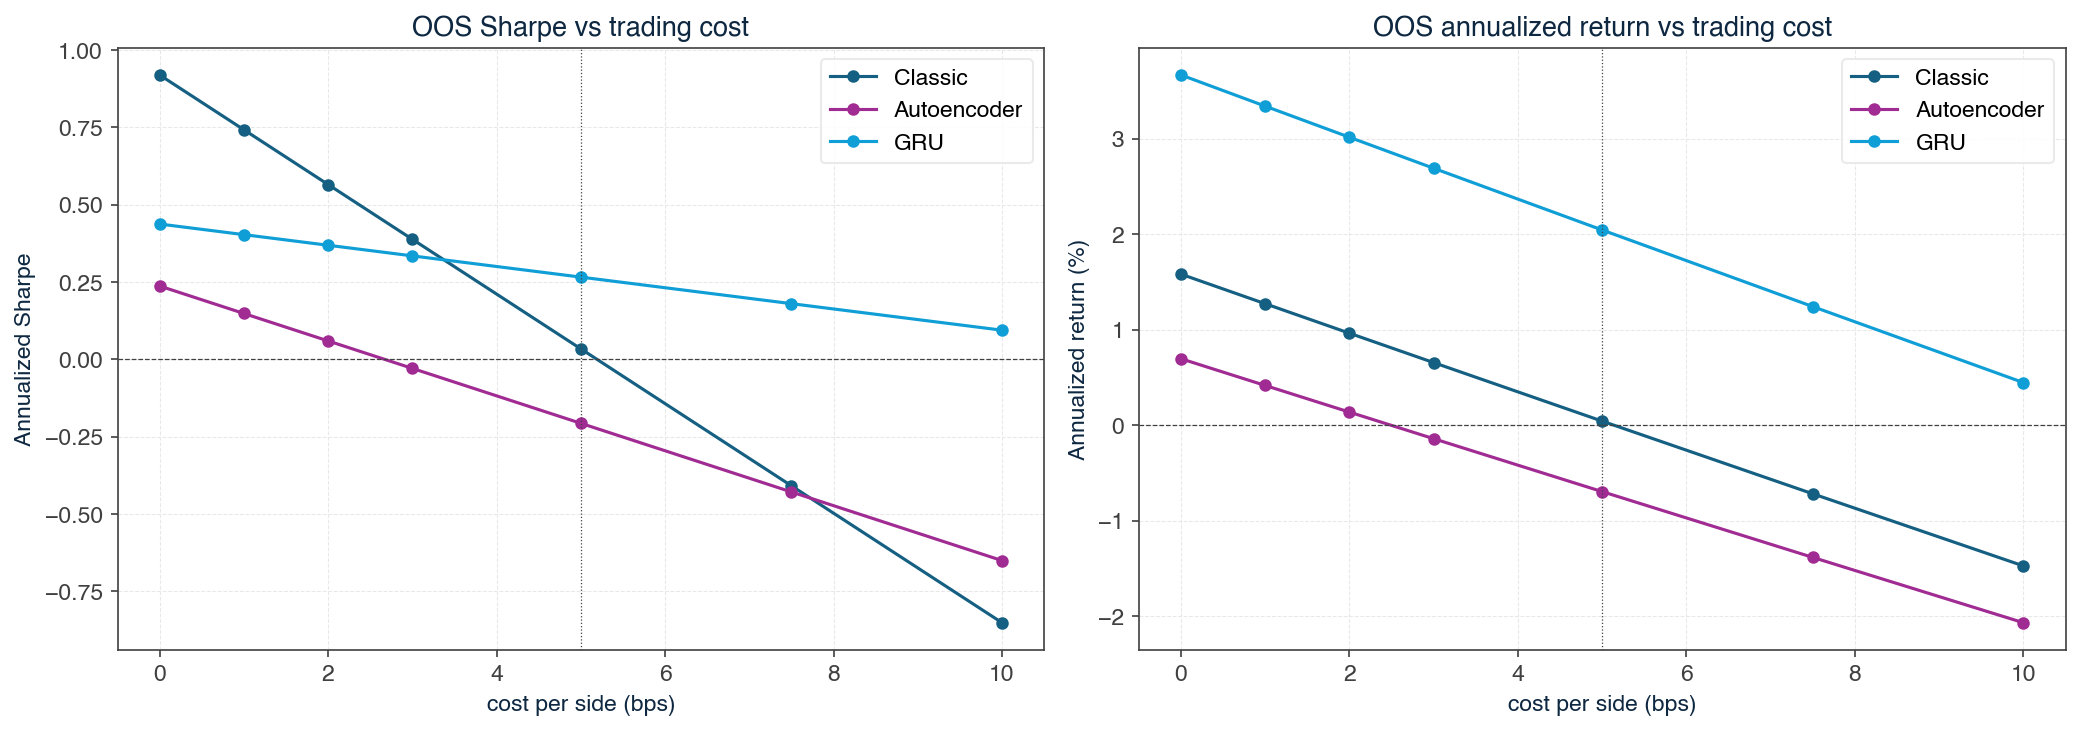

In [7]:
cost_grid_bps = np.array([0, 1, 2, 3, 5, 7.5, 10])
base_cost = 5e-4
cost_results = []

for arm in ARMS:
    eq = equity[arm]
    net_ret = eq.pct_change().fillna(0.0)
    turn_per_bar = agg[arm]["turnover_per_bar"]
    gross_ret = net_ret + turn_per_bar * base_cost
    for c_bps in cost_grid_bps:
        c = c_bps * 1e-4
        new_net = gross_ret - turn_per_bar * c
        r = new_net.dropna()
        sharpe = float(r.mean() / r.std() * np.sqrt(BARS_PER_YEAR)) if r.std() > 0 else 0.0
        ann_ret = float((1 + r).prod() ** (BARS_PER_YEAR / len(r)) - 1)
        cost_results.append({"arm": arm, "cost_bps": c_bps, "sharpe": sharpe, "ann_return": ann_ret})

cost_df = pd.DataFrame(cost_results)
cost_df.to_csv(RESULTS / "cost_sensitivity.tsv", sep="\t", index=False, float_format="%.6f")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for arm in ARMS:
    sub = cost_df[cost_df["arm"] == arm]
    ax1.plot(sub["cost_bps"], sub["sharpe"], marker="o", markersize=5,
             label=ARM_LABELS[arm], color=ARM_COLORS[arm], linewidth=1.5)
    ax2.plot(sub["cost_bps"], sub["ann_return"] * 100, marker="o", markersize=5,
             label=ARM_LABELS[arm], color=ARM_COLORS[arm], linewidth=1.5)

ax1.axhline(0, color=C_GRAY, linewidth=0.6, linestyle="--")
ax1.axvline(5, color=C_GRAY, linewidth=0.6, linestyle=":")
ax1.set_title("OOS Sharpe vs trading cost")
ax1.set_xlabel("cost per side (bps)")
ax1.set_ylabel("Annualized Sharpe")
ax1.legend()

ax2.axhline(0, color=C_GRAY, linewidth=0.6, linestyle="--")
ax2.axvline(5, color=C_GRAY, linewidth=0.6, linestyle=":")
ax2.set_title("OOS annualized return vs trading cost")
ax2.set_xlabel("cost per side (bps)")
ax2.set_ylabel("Annualized return (%)")
ax2.legend()
fig.tight_layout()
savefig(fig, "robustness_cost_sensitivity")

## 6. Universe coverage (EDA)

Loading years:   0%|          | 0/10 [00:00<?, ?yr/s]

Loading years:  10%|█         | 1/10 [00:00<00:07,  1.20yr/s]

Loading years:  20%|██        | 2/10 [00:01<00:07,  1.02yr/s]

Loading years:  30%|███       | 3/10 [00:02<00:06,  1.02yr/s]

Loading years:  40%|████      | 4/10 [00:04<00:06,  1.08s/yr]

...

Loading years:  90%|█████████ | 9/10 [00:11<00:01,  1.55s/yr]

Loading years: 100%|██████████| 10/10 [00:13<00:00,  1.66s/yr]

Loading years: 100%|██████████| 10/10 [00:13<00:00,  1.38s/yr]

/var/folders/93/8j44xjmx295fv2xk4njb739m0000gs/T/ipykernel_89067/3540698618.py:22: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = close.notna().groupby(ny.to_period("M")).mean()


  -> eda_universe.png


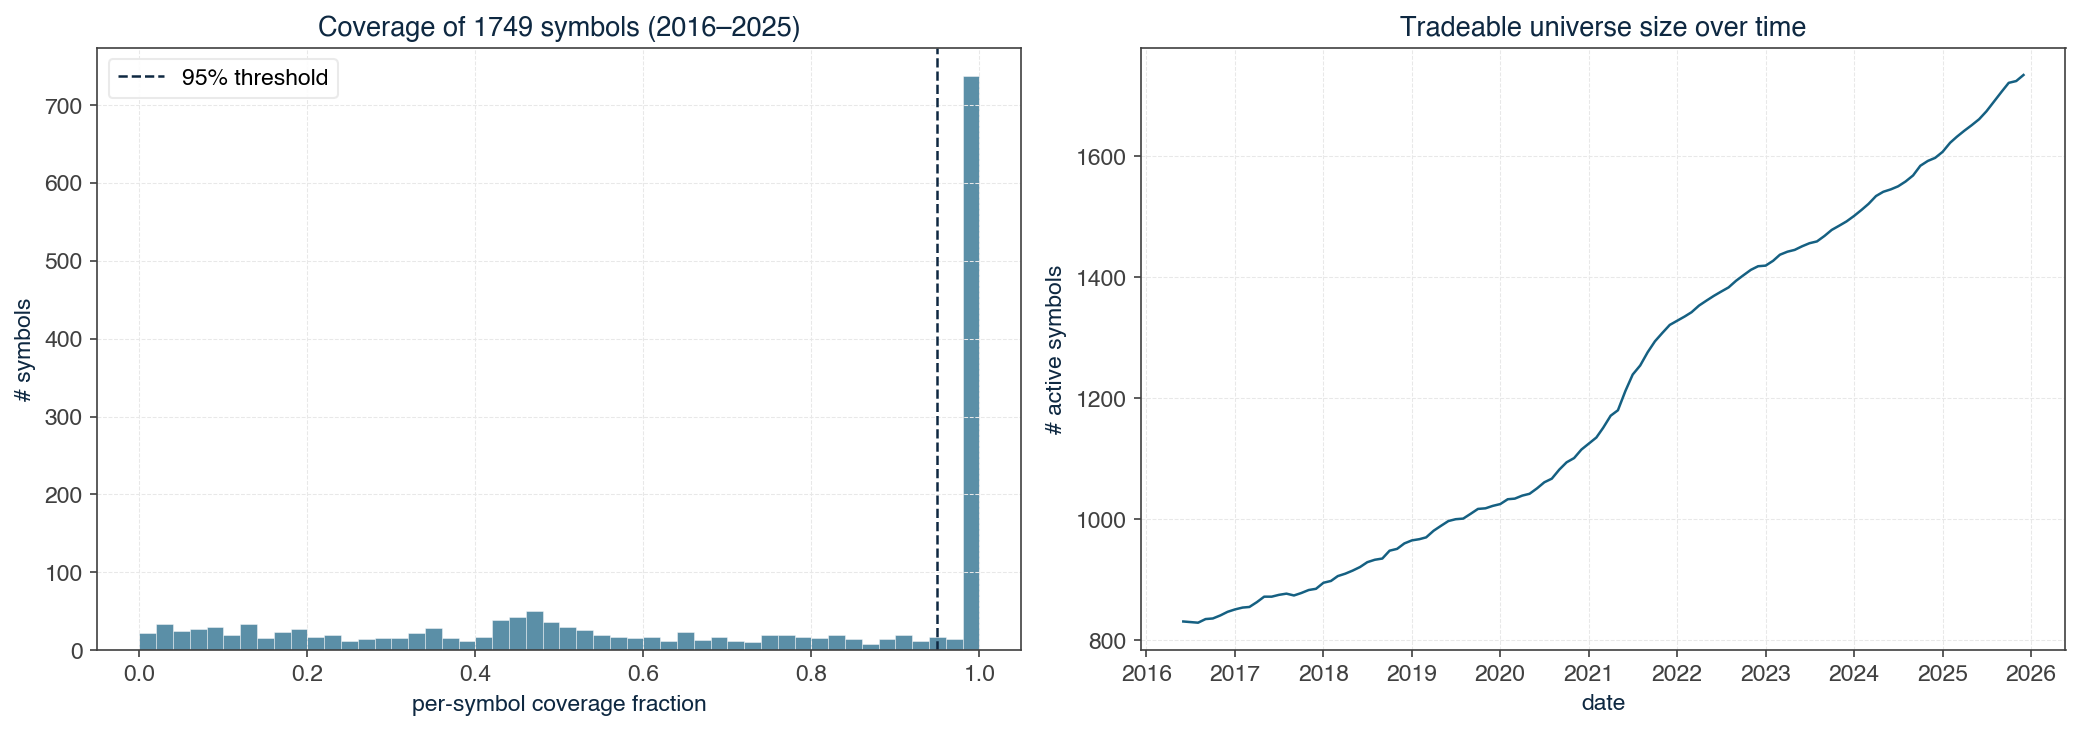

In [8]:
# Load price panel to compute coverage stats
import sys; sys.path.insert(0, str(ROOT))
from scripts.data_panel import build_price_panel

years = list(range(2016, 2026))
close = build_price_panel(years)
coverage = close.notna().mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: coverage histogram
ax1.hist(coverage, bins=50, color=C_TEAL, alpha=0.7, edgecolor="white", linewidth=0.3)
ax1.axvline(0.95, color=C_NAVY, linewidth=1.2, linestyle="--", label="95% threshold")
n_above = (coverage >= 0.95).sum()
ax1.set_title(f"Coverage of {len(coverage)} symbols (2016\u20132025)")
ax1.set_xlabel("per-symbol coverage fraction")
ax1.set_ylabel("# symbols")
ax1.legend()

# Right: active symbols over time
ny = close.index.tz_convert("America/New_York")
monthly = close.notna().groupby(ny.to_period("M")).mean()
active = (monthly > 0).sum(axis=1)
dates = active.index.to_timestamp()
ax2.plot(dates, active.values, color=C_TEAL, linewidth=1.2)
ax2.set_title("Tradeable universe size over time")
ax2.set_xlabel("date")
ax2.set_ylabel("# active symbols")

fig.tight_layout()
savefig(fig, "eda_universe")

# Save EDA summary
eda_summary = {
    "n_symbols": int(len(coverage)),
    "n_above_95pct": int(n_above),
    "total_bars": int(close.shape[0]),
    "date_range": [str(close.index[0]), str(close.index[-1])],
}
with open(RESULTS / "eda_summary.json", "w") as f:
    json.dump(eda_summary, f, indent=2)

## 7. Active pairs per fold

  -> active_pairs_per_fold.png


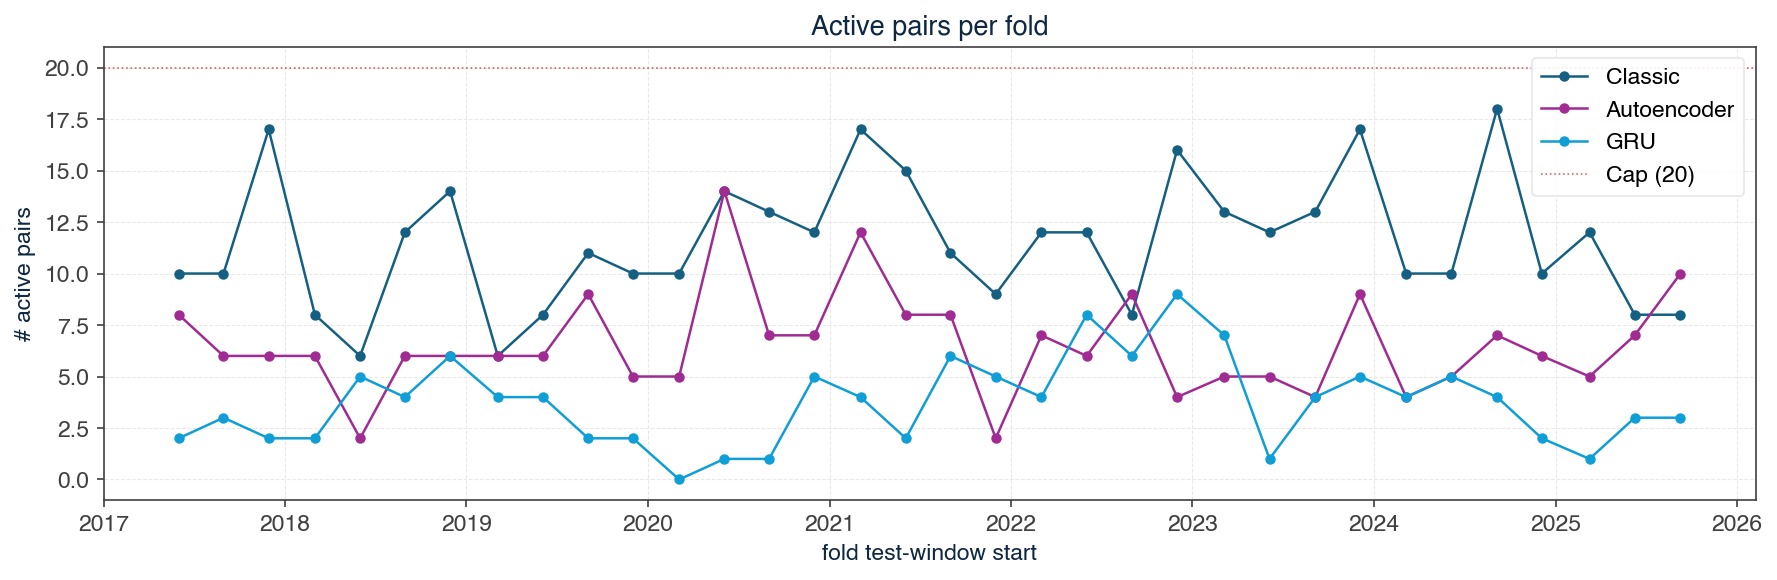

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
for arm in ARMS:
    fm = fold_metrics[arm]
    dates = pd.to_datetime(fm["test_start"])
    ax.plot(dates, fm["n_active_pairs"], marker="o", markersize=4,
            label=ARM_LABELS[arm], color=ARM_COLORS[arm], linewidth=1.2)
ax.axhline(20, color=C_MAROON, linewidth=0.8, linestyle=":", alpha=0.6, label="Cap (20)")
ax.set_title("Active pairs per fold")
ax.set_ylabel("# active pairs")
ax.set_xlabel("fold test-window start")
ax.legend()
fig.tight_layout()
savefig(fig, "active_pairs_per_fold")

## 8. Most traded pairs

  -> top_traded_pairs.png


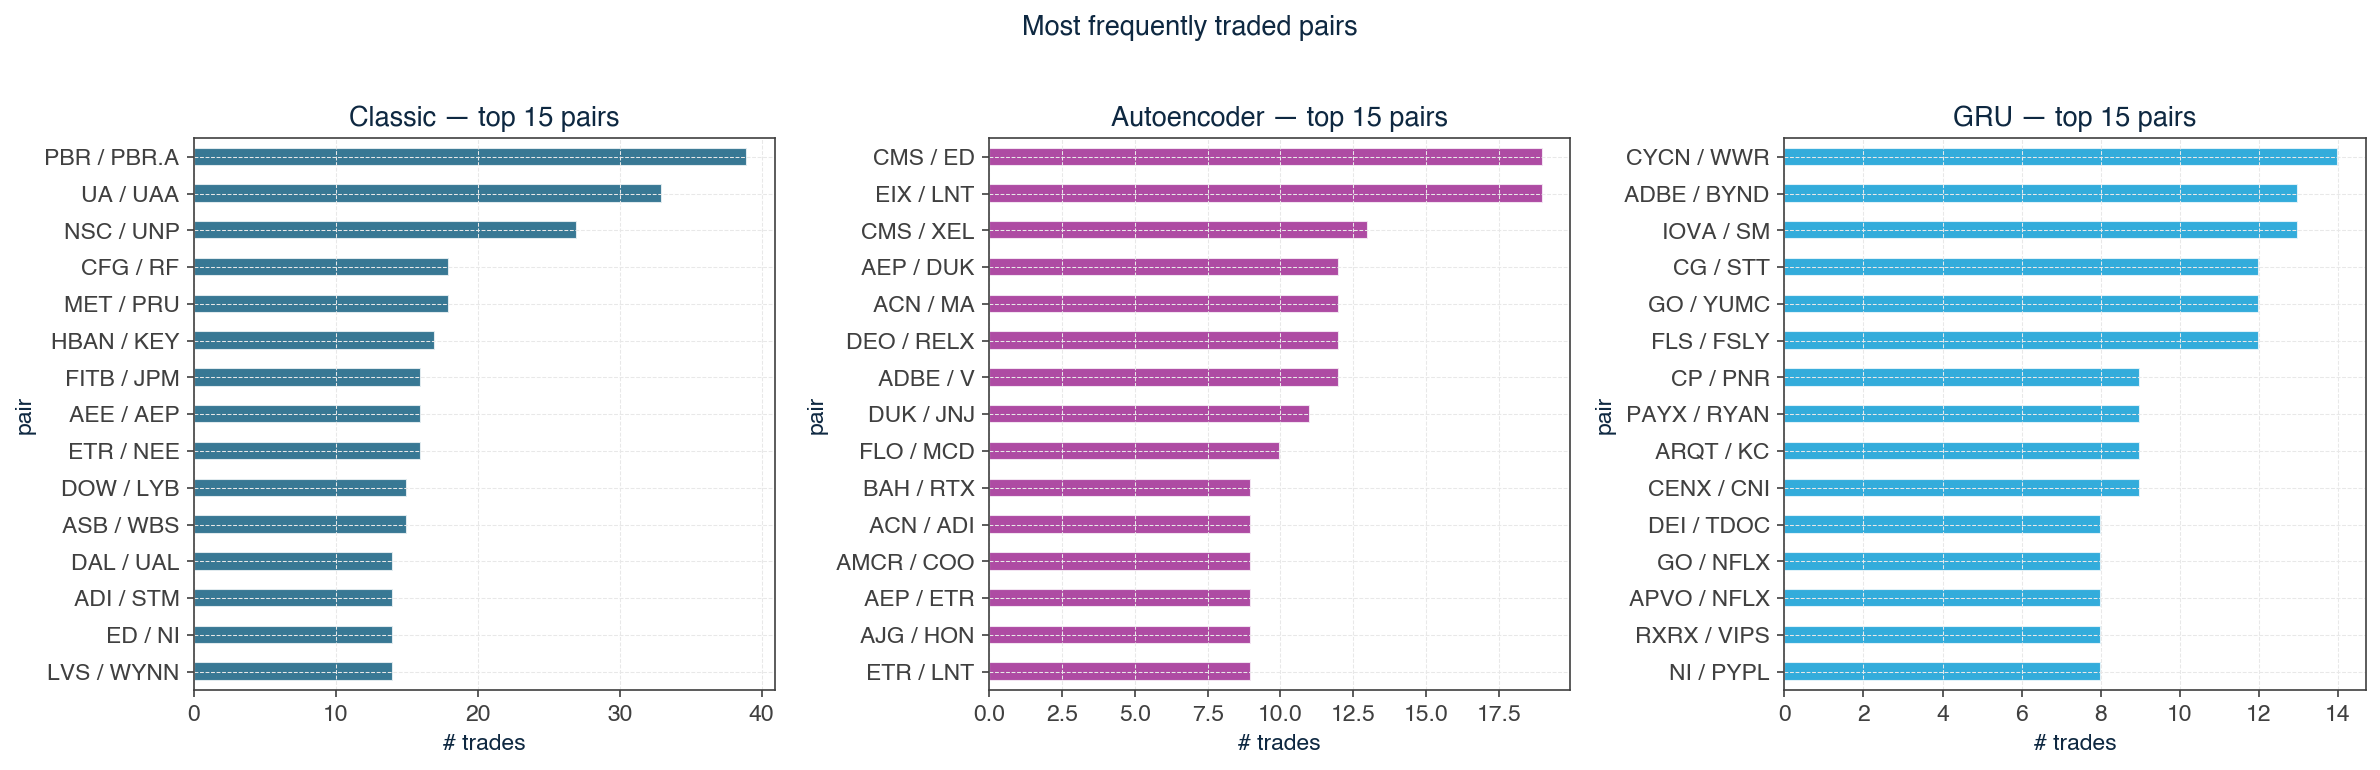

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, arm in zip(axes, ARMS):
    tl = trade_logs[arm].copy()
    if len(tl) == 0:
        ax.set_title(f"{ARM_LABELS[arm]} \u2014 no trades"); continue
    tl["pair"] = tl["sym_a"] + " / " + tl["sym_b"]
    top = tl["pair"].value_counts().head(15)
    top[::-1].plot.barh(ax=ax, color=ARM_COLORS[arm], alpha=0.85, edgecolor="white")
    ax.set_title(f"{ARM_LABELS[arm]} \u2014 top 15 pairs")
    ax.set_xlabel("# trades")
fig.suptitle("Most frequently traded pairs", fontweight="bold", color=C_NAVY, fontsize=13, y=1.02)
fig.tight_layout()
savefig(fig, "top_traded_pairs")

## 9. Pair overlap (Jaccard)

  -> pair_overlap_jaccard.png
Unique pairs: {'Classic': 276, 'Autoencoder': 206, 'GRU': 126}


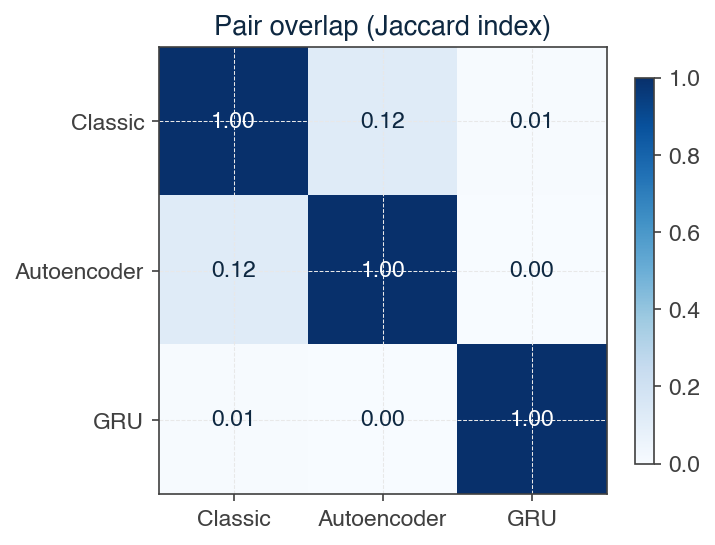

In [11]:
pair_sets = {}
for arm in ARMS:
    tl = trade_logs[arm]
    pairs = set()
    for _, row in tl.iterrows():
        a, b = row["sym_a"], row["sym_b"]
        pairs.add((min(a,b), max(a,b)))
    pair_sets[arm] = pairs

jaccard = np.zeros((3, 3))
for i, a1 in enumerate(ARMS):
    for j, a2 in enumerate(ARMS):
        s1, s2 = pair_sets[a1], pair_sets[a2]
        jaccard[i, j] = len(s1 & s2) / len(s1 | s2) if len(s1 | s2) > 0 else 0

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(jaccard, cmap="Blues", vmin=0, vmax=1)
labels = [ARM_LABELS[a] for a in ARMS]
ax.set_xticks(range(3)); ax.set_xticklabels(labels)
ax.set_yticks(range(3)); ax.set_yticklabels(labels)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{jaccard[i,j]:.2f}", ha="center", va="center",
                color="white" if jaccard[i,j] > 0.5 else C_NAVY, fontweight="bold")
ax.set_title("Pair overlap (Jaccard index)")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
savefig(fig, "pair_overlap_jaccard")

overlap_data = {"jaccard": jaccard.tolist(),
                "unique_pairs": {arm: len(pair_sets[arm]) for arm in ARMS}}
with open(RESULTS / "pair_overlap.json", "w") as f:
    json.dump(overlap_data, f, indent=2)
print("Unique pairs:", {ARM_LABELS[a]: len(pair_sets[a]) for a in ARMS})

## 10. Per-fold return heatmap

  -> fold_return_heatmap.png


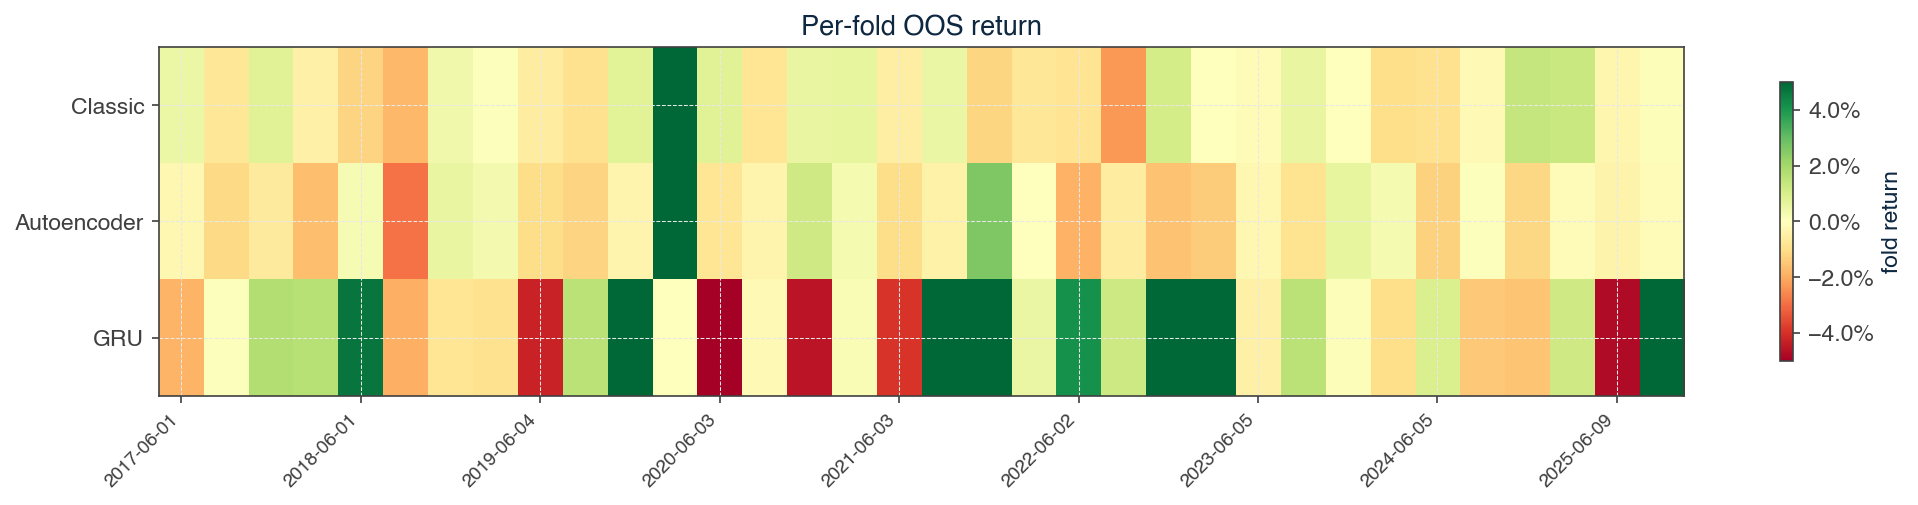

In [12]:
ret_matrix = pd.DataFrame({
    ARM_LABELS[arm]: fold_metrics[arm]["return_total"].values for arm in ARMS
}, index=fold_metrics["classic"]["test_start"].values)

fig, ax = plt.subplots(figsize=(14, 3.5))
im = ax.imshow(ret_matrix.T.values, aspect="auto", cmap="RdYlGn", vmin=-0.05, vmax=0.05)
ax.set_yticks(range(len(ARMS)))
ax.set_yticklabels([ARM_LABELS[a] for a in ARMS])
ax.set_xticks(np.arange(0, len(ret_matrix), 4))
ax.set_xticklabels(ret_matrix.index[::4], rotation=45, ha="right", fontsize=9)
ax.set_title("Per-fold OOS return")
cb = fig.colorbar(im, ax=ax, shrink=0.8, format=mtick.PercentFormatter(1.0, decimals=1))
cb.set_label("fold return")
fig.tight_layout()
savefig(fig, "fold_return_heatmap")

## 11. Summary bar chart

  -> summary_bars.png


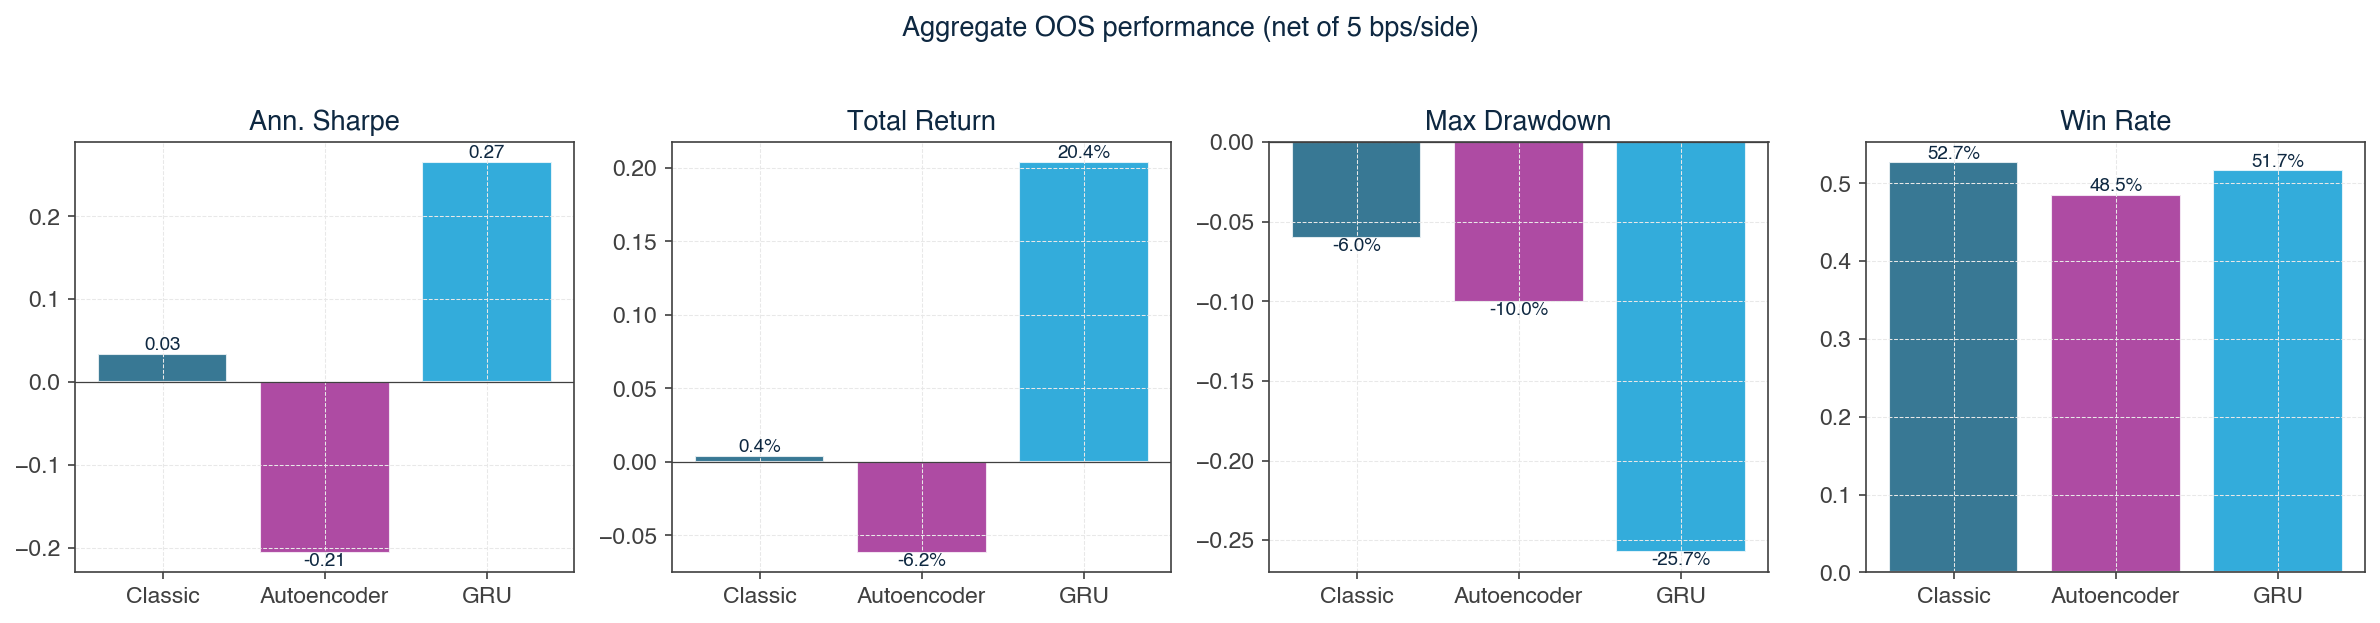

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
bar_metrics = [
    ("sharpe_annualized", "Ann. Sharpe", "{:.2f}"),
    ("return_total", "Total Return", "{:.1%}"),
    ("max_drawdown", "Max Drawdown", "{:.1%}"),
    ("trade_win_rate", "Win Rate", "{:.1%}"),
]
for ax, (key, title, fmt) in zip(axes, bar_metrics):
    vals = [agg[arm][key] for arm in ARMS]
    colors = [ARM_COLORS[arm] for arm in ARMS]
    bars = ax.bar([ARM_LABELS[a] for a in ARMS], vals, color=colors, alpha=0.85, edgecolor="white")
    ax.set_title(title)
    ax.axhline(0, color=C_GRAY, linewidth=0.6)
    for bar, val in zip(bars, vals):
        yoff = bar.get_height() if bar.get_height() >= 0 else bar.get_height()
        va = "bottom" if yoff >= 0 else "top"
        ax.text(bar.get_x() + bar.get_width()/2, yoff,
                fmt.format(val), ha="center", va=va, fontsize=9, fontweight="bold", color=C_NAVY)
fig.suptitle("Aggregate OOS performance (net of 5 bps/side)",
             fontweight="bold", color=C_NAVY, fontsize=13, y=1.03)
fig.tight_layout()
savefig(fig, "summary_bars")

## 12. Headline table

In [14]:
rows_spec = [
    ("Annualized Sharpe", "sharpe_annualized", ".2f"),
    ("Total return (net)", "return_total", ".1%"),
    ("Annualized return", "return_annualized", ".2%"),
    ("Max drawdown", "max_drawdown", ".1%"),
    ("Annualized turnover", "turnover_annualized", ".1f"),
    ("# trades", "n_trades", ".0f"),
    ("Trade win rate", "trade_win_rate", ".1%"),
    ("Avg holding (bars)", "avg_holding_bars", ".0f"),
    ("Avg pairs/fold", "n_active_pairs", ".1f"),
]
table_data = {}
for arm in ARMS:
    col = []
    for name, key, fmt in rows_spec:
        col.append(format(agg[arm][key], fmt))
    # % folds positive
    pct = (fold_metrics[arm]["sharpe_annualized"] > 0).mean()
    col.append(f"{pct:.0%}")
    table_data[ARM_LABELS[arm]] = col

idx = [n for n, _, _ in rows_spec] + ["% folds Sharpe>0"]
headline_df = pd.DataFrame(table_data, index=idx)
headline_df.to_csv(RESULTS / "headline_table.tsv", sep="\t")
display(headline_df)

,Classic,Autoencoder,GRU
Annualized Sharpe,0.03,-0.21,0.27
Total return (net),0.4%,-6.2%,20.4%
Annualized return,0.04%,-0.69%,2.05%
Max drawdown,-6.0%,-10.0%,-25.7%
Annualized turnover,30.5,27.8,31.6
# trades,1674,892,544
Trade win rate,52.7%,48.5%,51.7%
Avg holding (bars),56,62,55
Avg pairs/fold,11.5,6.5,3.7
% folds Sharpe>0,47%,32%,56%


## 13. Save equity TSVs and trade logs

In [15]:
eq_df = pd.DataFrame({ARM_LABELS[arm]: equity[arm] for arm in ARMS})
eq_df.index.name = "timestamp"
eq_df.to_csv(RESULTS / "equity_curves.tsv", sep="\t", float_format="%.6f")
for arm in ARMS:
    trade_logs[arm].to_csv(RESULTS / f"{arm}_trade_log.tsv", sep="\t", index=False)

print("\nAll results saved to:", RESULTS)
for f in sorted(RESULTS.iterdir()):
    print(f"  {f.name}")


All results saved to: /Users/simonpritchard/Documents/Academics/Senior_Year/MS&E_242/MS-E_242_pairs_trading/results
  active_pairs_per_fold.png
  autoencoder_equity_curve.png
  autoencoder_fold_metrics.tsv
  autoencoder_trade_log.tsv
  classic_equity_curve.png
  classic_fold_metrics.tsv
  classic_trade_log.tsv
  cost_sensitivity.tsv
  eda_fold_sharpe.png
  eda_summary.json
  eda_trade_dists.png
  eda_universe.png
  equity_curves.png
  equity_curves.tsv
  fold_return_heatmap.png
  gru_equity_curve.png
  gru_fold_metrics.tsv
  gru_trade_log.tsv
  headline_table.tsv
  pair_overlap.json
  pair_overlap_jaccard.png
  robustness_cost_sensitivity.png
  summary_bars.png
  summary_metrics.tsv
  top_traded_pairs.png
